In [1]:
!pip install -q pandas numpy scikit-learn nltk matplotlib seaborn joblib
!pip install -q google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [4]:
import pandas as pd
import numpy as np
import re
import zipfile
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
zip_path = "/content/archive.zip"
extract_path = "/content/email_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [7]:
os.listdir(extract_path)

['emails.csv']

In [8]:
csv_path = "/content/email_dataset/emails.csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None


In [10]:
print(df['spam'].value_counts())

spam
0    4360
1    1368
Name: count, dtype: int64


In [11]:
print(df.isnull().sum())

text    0
spam    0
dtype: int64


In [12]:
df = df.dropna(subset=['text', 'spam'])

print("Dataset after removing missing values:")
print(df.shape)

Dataset after removing missing values:
(5728, 2)


In [13]:
print("Duplicate emails:", df['text'].duplicated().sum())

Duplicate emails: 33


In [14]:
df = df.drop_duplicates(subset=['text'])

print("Dataset after removing duplicates:")
print(df.shape)

Dataset after removing duplicates:
(5695, 2)


In [15]:
df['label'] = df['spam'].map({
    0: 'ham',
    1: 'spam'
})

df[['text', 'spam', 'label']].head()

,text,spam,label
0,Subject: naturally irresistible your corporate...,1,spam
1,Subject: the stock trading gunslinger fanny i...,1,spam
2,Subject: unbelievable new homes made easy im ...,1,spam
3,Subject: 4 color printing special request add...,1,spam
4,"Subject: do not have money , get software cds ...",1,spam


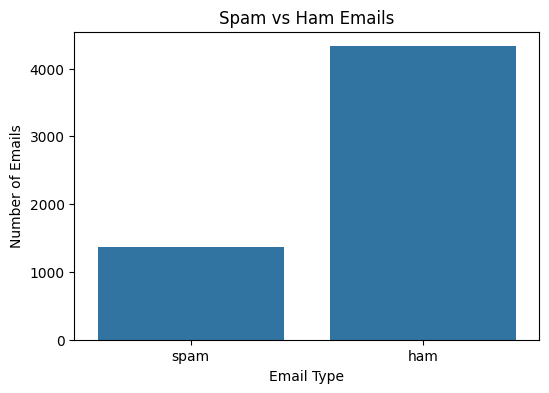

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='label'
)

plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.show()

In [17]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [18]:
df['clean_text'] = df['text'].apply(clean_text)

In [19]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject naturally irresistible corporate ident...
1,Subject: the stock trading gunslinger fanny i...,subject stock trading gunslinger fanny merrill...
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...
3,Subject: 4 color printing special request add...,subject color printing special request additio...
4,"Subject: do not have money , get software cds ...",subject money get software cds software compat...


In [20]:
X = df['clean_text']
y = df['spam']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

Training emails: 4556
Testing emails: 1139


In [22]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

In [23]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4556, 10000)
Testing TF-IDF shape: (1139, 10000)


In [24]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed!")

Model training completed!


In [25]:
y_pred = model.predict(X_test_tfidf)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 98.33 %


In [27]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

Precision: 99.61 %
Recall: 93.43 %
F1 Score: 96.42 %


In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       865
        Spam       1.00      0.93      0.96       274

    accuracy                           0.98      1139
   macro avg       0.99      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139



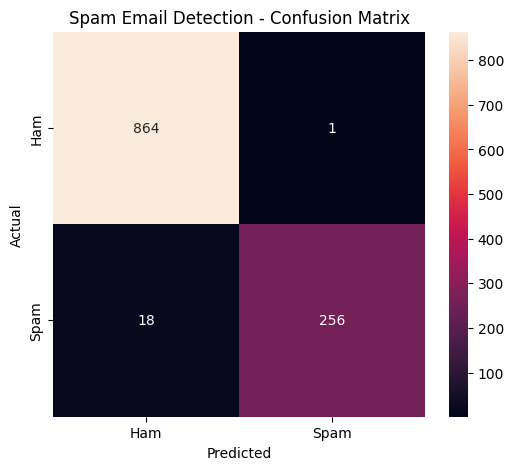

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Email Detection - Confusion Matrix")

plt.show()

In [30]:
def predict_email(email_text):

    # Clean email
    cleaned_email = clean_text(email_text)

    # Convert to TF-IDF
    email_vector = vectorizer.transform(
        [cleaned_email]
    )

    # Prediction
    prediction = model.predict(
        email_vector
    )[0]

    # Probability
    probabilities = model.predict_proba(
        email_vector
    )[0]

    if prediction == 1:

        result = "SPAM"
        confidence = probabilities[1]

    else:

        result = "HAM"
        confidence = probabilities[0]

    return result, confidence

In [31]:
email = """
Congratulations! You have won a $10,000 cash prize.
Click the link below to claim your reward immediately.
"""

result, confidence = predict_email(email)

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: SPAM
Confidence: 83.24 %


In [32]:
email = """
Hello John,

Please find attached the project report.
Let me know if you have any questions.

Regards,
Pritam
"""

result, confidence = predict_email(email)

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: HAM
Confidence: 99.69 %


In [33]:
email = """
Hello John,

Please find attached the project report.
Let me know if you have any questions.

Regards,
Pritam
"""

result, confidence = predict_email(email)

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: HAM
Confidence: 99.69 %


In [34]:
user_email = input("Enter your email text: ")

result, confidence = predict_email(user_email)

print("\n----------------------------")
print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")
print("----------------------------")

Enter your email text: Send me your CV you will get your job

----------------------------
Prediction: HAM
Confidence: 92.87 %
----------------------------


In [35]:
joblib.dump(
    model,
    "/content/spam_model.pkl"
)

joblib.dump(
    vectorizer,
    "/content/tfidf_vectorizer.pkl"
)

print("Model and vectorizer saved!")

Model and vectorizer saved!
